In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
folders = os.listdir('/content/drive/MyDrive/dataset')
print(folders)


['dyed-lifted-polyps', 'dyed-resection-margins', 'normal-pylorus', 'polyps', 'esophagitis', 'normal-cecum', 'normal-z-line', 'ulcerative-colitis']


Image count per class:
dyed-lifted-polyps: 1001
dyed-resection-margins: 1000
normal-pylorus: 1000
polyps: 1007
esophagitis: 1000
normal-cecum: 1000
normal-z-line: 1000
ulcerative-colitis: 1000


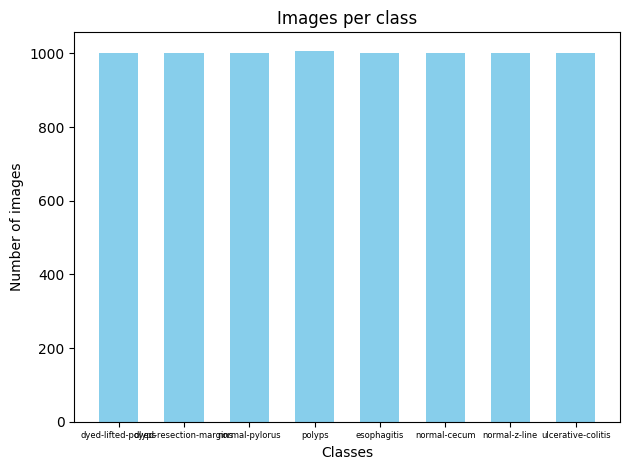

Dataset is relatively balanced ✅


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

dataset_path = '/content/drive/MyDrive/dataset'  
# جلب أسماء الفئات
classes = os.listdir(dataset_path)
image_count = {}

# عد الصور في كل كلاس
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
    image_count[cls] = count

# عرض النتيجة
print("Image count per class:")
for cls, count in image_count.items():
    print(f"{cls}: {count}")

# إعداد البار شارت
classes = list(image_count.keys())
counts = list(image_count.values())

x = np.arange(len(classes)) * 2  # زيادة المسافة بين الأعمدة
bar_width = 1.2  # عرض البار

plt.bar(x, counts, width=bar_width, color='skyblue')
plt.xlabel("Classes")
plt.ylabel("Number of images")
plt.title("Images per class")
plt.xticks(x, classes, fontsize=6)  # تصغير النص
plt.tight_layout()
plt.show()

# التحقق من التوازن
counts_list = list(image_count.values())
if max(counts_list) - min(counts_list) <= 0.1 * max(counts_list):
    print("Dataset is relatively balanced ✅")
else:
    print("Dataset is imbalanced ⚠️")


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

original_path = '/content/drive/MyDrive/dataset'
processed_path = '/content/drive/MyDrive/dataset_processed'
os.makedirs(processed_path, exist_ok=True)

# دالة البريبروسيس
def preprocess_image(img, img_size=(224,224)):
    # Convert BGR to RGB
    if len(img.shape) == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Noise reduction (Gaussian blur)
    img = cv2.GaussianBlur(img, (3,3), 0)

    # Convert to LAB
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = l.astype(np.uint8)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    # Ensure same size
    a = cv2.resize(a, (l.shape[1], l.shape[0]))
    b = cv2.resize(b, (l.shape[1], l.shape[0]))
    lab = cv2.merge([l,a,b])
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Resize
    img = cv2.resize(img, img_size)

    # Normalize
    img = img / 255.0

    return img

# معالجة كل الصور وحفظها
labels = []
for cls in os.listdir(original_path):
    cls_folder = os.path.join(original_path, cls)
    if not os.path.isdir(cls_folder): continue

    save_folder = os.path.join(processed_path, cls)
    os.makedirs(save_folder, exist_ok=True)

    print(f"[INFO] Processing class: {cls}")
    for img_name in tqdm(os.listdir(cls_folder)):
        img_path = os.path.join(cls_folder, img_name)
        img = cv2.imread(img_path)
        if img is None: continue

        processed_img = preprocess_image(img)
        # حفظ الصورة
        save_path = os.path.join(save_folder, img_name)
        cv2.imwrite(save_path, cv2.cvtColor((processed_img*255).astype(np.uint8), cv2.COLOR_RGB2BGR))
        labels.append(cls)

# Label Encoding + One-hot
le = LabelEncoder()
le.fit(labels)
print("Classes:", le.classes_)


[INFO] Processing class: dyed-lifted-polyps


100%|██████████| 1001/1001 [07:00<00:00,  2.38it/s]


[INFO] Processing class: dyed-resection-margins


100%|██████████| 1000/1000 [06:34<00:00,  2.53it/s]


[INFO] Processing class: normal-pylorus


...

[INFO] Processing class: normal-z-line


100%|██████████| 1000/1000 [07:42<00:00,  2.16it/s]


[INFO] Processing class: ulcerative-colitis


100%|██████████| 1000/1000 [06:28<00:00,  2.57it/s]

Classes: ['dyed-lifted-polyps' 'dyed-resection-margins' 'esophagitis'
 'normal-cecum' 'normal-pylorus' 'normal-z-line' 'polyps'
 'ulcerative-colitis']


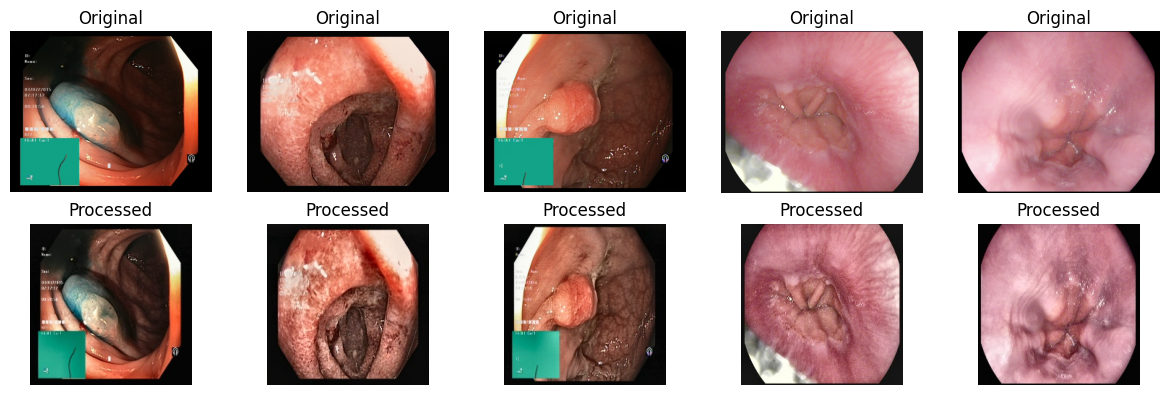

In [ ]:
import matplotlib.pyplot as plt
import random

def show_random_images(original_path, processed_path, n=5):
    classes = [c for c in os.listdir(original_path) if os.path.isdir(os.path.join(original_path,c))]
    plt.figure(figsize=(12,4))
    for i in range(n):
        cls = random.choice(classes)
        img_name = random.choice(os.listdir(os.path.join(original_path, cls)))

        orig_img = cv2.imread(os.path.join(original_path, cls, img_name))
        proc_img = cv2.imread(os.path.join(processed_path, cls, img_name))

        # Original
        plt.subplot(2,n,i+1)
        plt.imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.axis('off')

        # Processed
        plt.subplot(2,n,i+1+n)
        plt.imshow(cv2.cvtColor(proc_img, cv2.COLOR_BGR2RGB))
        plt.title("Processed")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_random_images(original_path, processed_path, n=5)


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import shutil
from sklearn.model_selection import train_test_split

processed_path = '/content/drive/MyDrive/dataset_processed' 
split_path = '/content/drive/MyDrive/dataset_split'           
os.makedirs(split_path, exist_ok=True)

splits = ['train', 'val', 'test']
for split in splits:
    os.makedirs(os.path.join(split_path, split), exist_ok=True)

for cls in os.listdir(processed_path):
    cls_folder = os.path.join(processed_path, cls)
    if not os.path.isdir(cls_folder):
        continue

    # قراءة كل الصور
    imgs = os.listdir(cls_folder)

    # تقسيم 80% train و 20% temp
    train_imgs, temp_imgs = train_test_split(imgs, test_size=0.2, random_state=42)

    # تقسيم temp 50/50 → 10% val و 10% test
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    # نسخ الصور لكل مجلد
    for split_name, split_imgs in zip(splits, [train_imgs, val_imgs, test_imgs]):
        split_cls_folder = os.path.join(split_path, split_name, cls)
        os.makedirs(split_cls_folder, exist_ok=True)

        for img_name in split_imgs:
            src = os.path.join(cls_folder, img_name)
            dst = os.path.join(split_cls_folder, img_name)
            shutil.copy(src, dst)

print("✅ Data splitting completed: Train 80%, Val 10%, Test 10%")


✅ Data splitting completed: Train 80%, Val 10%, Test 10%


In [ ]:
import shutil

# لو الفولدر موجود امسحيه علشان مايحصلش conflict
shutil.rmtree('/content/dataset_split', ignore_errors=True)

# انسخي الفولدر من Drive → الرام
shutil.copytree('/content/drive/MyDrive/dataset_split', '/content/dataset_split')

print("Dataset copied to RAM ✔️")


Dataset copied to RAM ✔️


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


base_path = '/content/dataset_split'  
img_size = (224,224)
batch_size = 32


train_datagen = ImageDataGenerator(
    rotation_range=20,       
    width_shift_range=0.1,   
    height_shift_range=0.1,   
    horizontal_flip=True,    
    zoom_range=0.1, 
    brightness_range=[0.8,1.2],
    shear_range=0.1,
    channel_shift_range=10,
    rescale=None
)

train_generator = train_datagen.flow_from_directory(
    directory=f'{base_path}/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)


val_datagen = ImageDataGenerator(rescale=None )  # فقط batching
val_generator = val_datagen.flow_from_directory(
    directory=f'{base_path}/val',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


test_datagen = ImageDataGenerator(rescale=None )  # فقط batching
test_generator = test_datagen.flow_from_directory(
    directory=f'{base_path}/test',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 7148 images belonging to 8 classes.
Found 1211 images belonging to 8 classes.
Found 1224 images belonging to 8 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import  ModelCheckpoint, ReduceLROnPlateau

base_model = EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = True

for layer in base_model.layers[:-60]:
    layer.trainable = False

#  إضافة طبقات الـ Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)  
outputs = Dense(train_generator.num_classes,
                activation='softmax',
                kernel_regularizer=l2(0.001))(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_efficientnetB3_model.h5',
    monitor='val_accuracy',
    save_best_only=True ,
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=65,
    callbacks=[checkpoint, lr_reduce]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/65
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.2216 - loss: 2.0234
Epoch 1: val_accuracy improved from -inf to 0.62923, saving model to /content/drive/MyDrive/best_efficientnetB3_model.h5


224/224 ━━━━━━━━━━━━━━━━━━━━ 232s 756ms/step - accuracy: 0.2220 - loss: 2.0226 - val_accuracy: 0.6292 - val_loss: 1.4051 - learning_rate: 1.0000e-05
Epoch 2/65
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.5746 - loss: 1.3708
Epoch 2: val_accuracy improved from 0.62923 to 0.78778, saving model to /content/drive/MyDrive/best_efficientnetB3_model.h5


224/224 ━━━━━━━━━━━━━━━━━━━━ 110s 491ms/step - accuracy: 0.5748 - loss: 1.3703 - val_accuracy: 0.7878 - val_loss: 0.9487 - learning_rate: 1.0000e-05
Epoch 3/65
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.7188 - loss: 0.9735
Epoch 3: val_accuracy improved from 0.78778 to 0.83650, saving model to /content/drive/MyDrive/best_efficientnetB3_model.h5


224/224 ━━━━━━━━━━━━━━━━━━━━ 110s 490ms/step - accuracy: 0.7188 - loss: 0.9733 - val_accuracy: 0.8365 - val_loss: 0.6750 - learning_rate: 1.0000e-05
Epoch 4/65
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.7796 - loss: 0.7460
Epoch 4: val_accuracy improved from 0.83650 to 0.86623, saving model to /content/drive/MyDrive/best_efficientnetB3_model.h5


...

224/224 ━━━━━━━━━━━━━━━━━━━━ 110s 488ms/step - accuracy: 0.9472 - loss: 0.1595 - val_accuracy: 0.9488 - val_loss: 0.1595 - learning_rate: 1.0000e-05
Epoch 47/65
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9423 - loss: 0.1685
Epoch 47: val_accuracy did not improve from 0.94880

Epoch 47: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
224/224 ━━━━━━━━━━━━━━━━━━━━ 137s 468ms/step - accuracy: 0.9423 - loss: 0.1685 - val_accuracy: 0.9463 - val_loss: 0.1580 - learning_rate: 1.0000e-05
Epoch 48/65
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9454 - loss: 0.1620
Epoch 48: val_accuracy did not improve from 0.94880
224/224 ━━━━━━━━━━━━━━━━━━━━ 105s 468ms/step - accuracy: 0.9454 - loss: 0.1619 - val_accuracy: 0.9472 - val_loss: 0.1545 - learning_rate: 5.0000e-06
Epoch 49/65
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.9475 - loss: 0.1489
Epoch 49: val_accuracy did not improve from 0.94880
224/224 ━━━━━━━━━━━━━━━━━━━━ 106s 475ms/step - accur


Epoch 53: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
224/224 ━━━━━━━━━━━━━━━━━━━━ 108s 481ms/step - accuracy: 0.9490 - loss: 0.1518 - val_accuracy: 0.9496 - val_loss: 0.1549 - learning_rate: 5.0000e-06
Epoch 54/65
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9466 - loss: 0.1465
Epoch 54: val_accuracy improved from 0.94963 to 0.95045, saving model to /content/drive/MyDrive/best_efficientnetB3_model.h5


224/224 ━━━━━━━━━━━━━━━━━━━━ 110s 493ms/step - accuracy: 0.9466 - loss: 0.1465 - val_accuracy: 0.9505 - val_loss: 0.1525 - learning_rate: 2.5000e-06
Epoch 55/65
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.9543 - loss: 0.1394
Epoch 55: val_accuracy did not improve from 0.95045
224/224 ━━━━━━━━━━━━━━━━━━━━ 107s 477ms/step - accuracy: 0.9543 - loss: 0.1394 - val_accuracy: 0.9505 - val_loss: 0.1520 - learning_rate: 2.5000e-06
Epoch 56/65
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9493 - loss: 0.1484
Epoch 56: val_accuracy improved from 0.95045 to 0.95128, saving model to /content/drive/MyDrive/best_efficientnetB3_model.h5


224/224 ━━━━━━━━━━━━━━━━━━━━ 108s 484ms/step - accuracy: 0.9493 - loss: 0.1484 - val_accuracy: 0.9513 - val_loss: 0.1526 - learning_rate: 2.5000e-06
Epoch 57/65
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.9571 - loss: 0.1383
Epoch 57: val_accuracy did not improve from 0.95128
224/224 ━━━━━━━━━━━━━━━━━━━━ 107s 477ms/step - accuracy: 0.9570 - loss: 0.1383 - val_accuracy: 0.9496 - val_loss: 0.1530 - learning_rate: 2.5000e-06
Epoch 58/65
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.9492 - loss: 0.1497
Epoch 58: val_accuracy did not improve from 0.95128
224/224 ━━━━━━━━━━━━━━━━━━━━ 106s 472ms/step - accuracy: 0.9492 - loss: 0.1497 - val_accuracy: 0.9513 - val_loss: 0.1514 - learning_rate: 2.5000e-06
Epoch 59/65
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9441 - loss: 0.1494
Epoch 59: val_accuracy did not improve from 0.95128
224/224 ━━━━━━━━━━━━━━━━━━━━ 105s 470ms/step - accuracy: 0.9441 - loss: 0.1494 - val_accuracy: 0.9496 - val_loss: 0.1508 - learnin

224/224 ━━━━━━━━━━━━━━━━━━━━ 110s 491ms/step - accuracy: 0.9561 - loss: 0.1383 - val_accuracy: 0.9521 - val_loss: 0.1498 - learning_rate: 1.2500e-06
Epoch 65/65
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.9518 - loss: 0.1395
Epoch 65: val_accuracy did not improve from 0.95211
224/224 ━━━━━━━━━━━━━━━━━━━━ 107s 477ms/step - accuracy: 0.9519 - loss: 0.1395 - val_accuracy: 0.9521 - val_loss: 0.1505 - learning_rate: 1.2500e-06


In [ ]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]

print(f"✅ Final Train Accuracy: {final_train_acc*100:.2f}%")
print(f"✅ Final Validation Accuracy: {final_val_acc*100:.2f}%")

✅ Final Train Accuracy: 95.27%
✅ Final Validation Accuracy: 95.21%


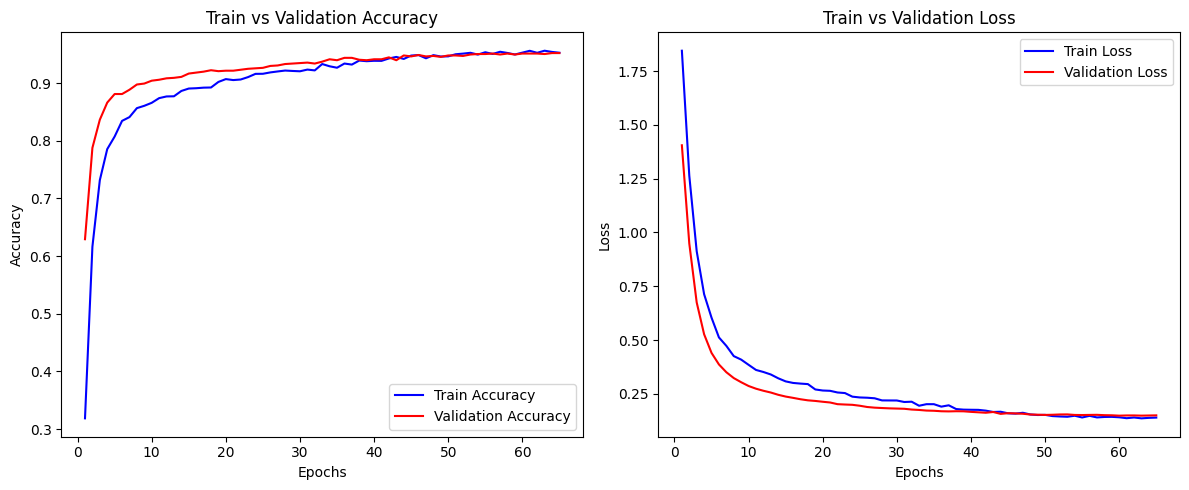

In [ ]:
import matplotlib.pyplot as plt


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b', label='Train Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Train vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b', label='Train Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Train vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")

39/39 ━━━━━━━━━━━━━━━━━━━━ 29s 420ms/step - accuracy: 0.9438 - loss: 0.1556
✅ Test Accuracy: 95.26%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# التوقعات
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

# Classification Report
cr = classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys())
print("Classification Report:\n", cr)

39/39 ━━━━━━━━━━━━━━━━━━━━ 22s 321ms/step
Confusion Matrix:
 [[153   4   0   0   0   0   0   0]
 [  9 136   0   0   0   0   0   0]
 [  0   0 119   0   2  26   0   0]
 [  0   0   0 154   0   0   0   0]
 [  0   0   0   0 153   1   0   0]
 [  0   0  12   0   0 139   0   0]
 [  0   0   0   1   0   0 158   1]
 [  0   0   0   0   0   0   2 154]]
Classification Report:
                         precision    recall  f1-score   support

    dyed-lifted-polyps       0.94      0.97      0.96       157
dyed-resection-margins       0.97      0.94      0.95       145
           esophagitis       0.91      0.81      0.86       147
          normal-cecum       0.99      1.00      1.00       154
        normal-pylorus       0.99      0.99      0.99       154
         normal-z-line       0.84      0.92      0.88       151
                polyps       0.99      0.99      0.99       160
    ulcerative-colitis       0.99      0.99      0.99       156

              accuracy                           0.95   

39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step


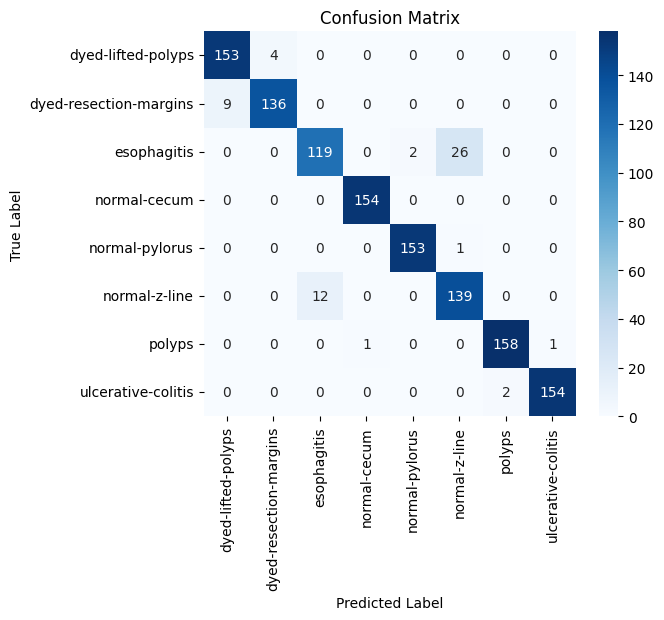

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())


cm = confusion_matrix(y_true, y_pred_classes)


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

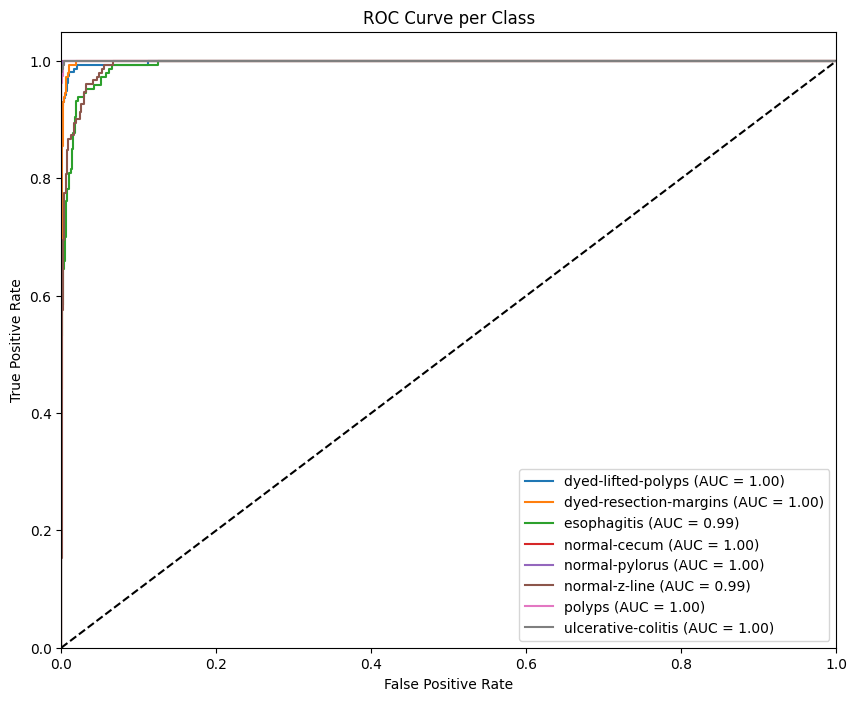

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get class names from the test_generator
class_names = list(test_generator.class_indices.keys())

# One-hot encoding للـ labels
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]

plt.figure(figsize=(10,8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_pred[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')  # خط الRandom
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend(loc='lower right')
plt.show()

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.applications.resnet_v2 import preprocess_input


def load_and_preprocess_image(img_path, target_size=(224,224)):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("الصورة مش موجودة أو المسار غلط")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = np.expand_dims(img, axis=0)  # إضافة batch dimension
    img = preprocess_input(img)  # لازم زي ما عملنا في الـ train
    return img

img_path = '/content/drive/MyDrive/dataset_split/test/ulcerative-colitis/02daad2b-534a-4822-96ab-0d42d23a3fb9.jpg'  
img = load_and_preprocess_image(img_path)


pred_prob = model.predict(img)  # probability لكل كلاس
pred_class = np.argmax(pred_prob, axis=1)[0]  # index للكلاس المتوقع

class_labels = list(train_generator.class_indices.keys())  # أسماء الكلاسات
print(f"الصورة تنتمي لكلاس: {class_labels[pred_class]}")
print(f"احتمالية كل كلاس: {pred_prob}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
الصورة تنتمي لكلاس: ulcerative-colitis
احتمالية كل كلاس: [[0.1096613  0.09318526 0.13223307 0.15159108 0.13384312 0.11282876
  0.0804766  0.18618083]]
